1.

1. We use General Linear Models in order too handle non lineararity, complex distributions, and unobservable traits. General Linear Models can handle more complex data than standard linear models can.
2. Binary Cross Entropy and Categorical Cross Entropy are effective because they leverage logarithmic scaling in order to align the penalty of the model with the reality of probability.
3. True, linear regression is linear in its parameters and the decision boundary is also linear. It models a linear combination of features passed through a sigmoid function.
4. False, logistic regression is a very common classification algorithm that outputs a probability that maps to a class label.
5. No, the coefficent represents the change in the log-odds of the outcome for a 1-unit change.
6. False, logistic regression is still a linear model so feature engineering is still very important.
7. False, ordinary logistic regression and logistic regression are for different things. Ordinary logistics regression is for continuous outcomes while the logistic regression is for binary or categorical outcomes. You make the decision to choose either method based on your response variable.  

2.

Dropout % by Scholarship status:
Target                Dropout   Graduate
Scholarship holder                      
0                   48.365276  51.634724
1                   13.828689  86.171311


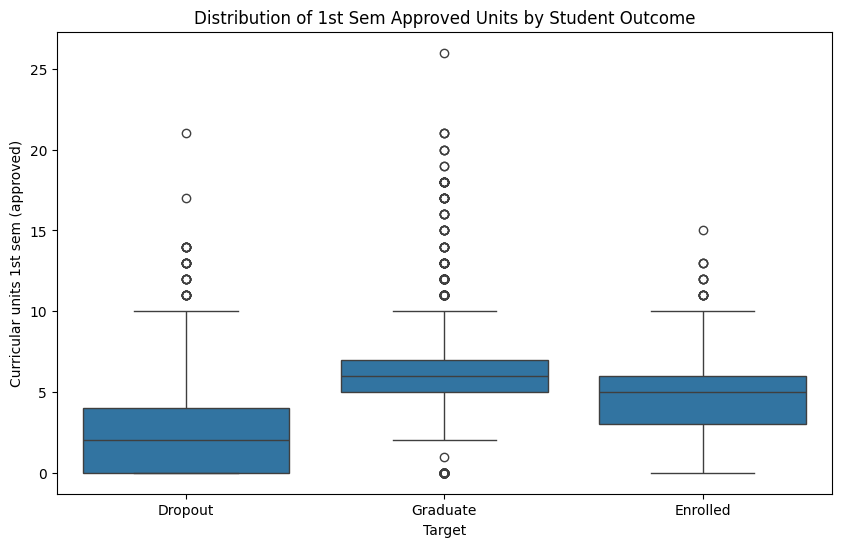


Correlation between Target and Inflation rate: -0.0269
Correlation between Target and GDP: 0.0441


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data.csv', sep=';')

df_filtered = df[df['Target'] != 'Enrolled']
scholarship_dropout = pd.crosstab(df_filtered['Scholarship holder'], df_filtered['Target'], normalize='index') * 100

print("Dropout % by Scholarship status:")
print(scholarship_dropout)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Target', y='Curricular units 1st sem (approved)', data=df)
plt.title('Distribution of 1st Sem Approved Units by Student Outcome')
plt.show()

target_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df['Target_numeric'] = df['Target'].map(target_mapping)

corr_inflation = df['Target_numeric'].corr(df['Inflation rate'])
corr_gdp = df['Target_numeric'].corr(df['GDP'])

print(f"\nCorrelation between Target and Inflation rate: {corr_inflation:.4f}")
print(f"Correlation between Target and GDP: {corr_gdp:.4f}")

/tmp/ipykernel_4734/2226800441.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats = df.groupby('Age_Group')['Target'].value_counts(normalize=True).unstack() * 100
/tmp/ipykernel_4734/2226800441.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_stats.index, y=age_stats['Dropout'], palette='viridis')


Percentage of Outcomes by Age Group:
Target       Dropout   Enrolled   Graduate
Age_Group                                 
18-21      22.140865  18.793584  59.065551
22-25      39.920949  22.134387  37.944664
26-30      59.791123  14.882507  25.326371
31-40      55.148741  13.272311  31.578947
40+        50.450450  11.711712  37.837838


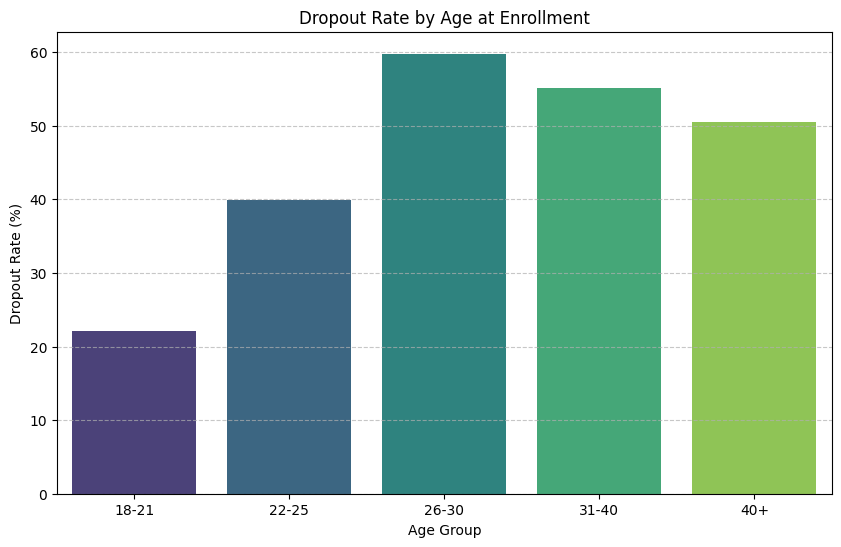

In [ ]:
bins = [17, 21, 25, 30, 40, 60]
labels = ['18-21', '22-25', '26-30', '31-40', '40+']
df['Age_Group'] = pd.cut(df['Age at enrollment'], bins=bins, labels=labels)

age_stats = df.groupby('Age_Group')['Target'].value_counts(normalize=True).unstack() * 100

print("Percentage of Outcomes by Age Group:")
print(age_stats)

plt.figure(figsize=(10, 6))
sns.barplot(x=age_stats.index, y=age_stats['Dropout'], palette='viridis')

plt.title('Dropout Rate by Age at Enrollment')
plt.xlabel('Age Group')
plt.ylabel('Dropout Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
df['is_dropout'] = (df['Target'] == 'Dropout').astype(int)

numeric_df = df.select_dtypes(include=['number'])
correlations = numeric_df.corr()['is_dropout'].sort_values()

print("Predictors of LOWER Dropout Risk (Negative Correlation)")
print(correlations.head(6))

print("\nPredictors of HIGHER Dropout Risk (Positive Correlation)")
print(correlations.tail(6).iloc[:-1])

tuition_impact = df.groupby('Tuition fees up to date')['Target'].value_counts(normalize=True).unstack() * 100
print("\n--- Impact of Tuition Status on Dropout Rate (%) ---")
print(tuition_impact[['Dropout']])

Predictors of LOWER Dropout Risk (Negative Correlation)
Target_numeric                        -0.912485
Curricular units 2nd sem (grade)      -0.571792
Curricular units 2nd sem (approved)   -0.569500
Curricular units 1st sem (grade)      -0.480669
Curricular units 1st sem (approved)   -0.479112
Tuition fees up to date               -0.429149
Name: is_dropout, dtype: float64

Predictors of HIGHER Dropout Risk (Positive Correlation)
Marital status       0.093712
Application mode     0.198458
Gender               0.203983
Debtor               0.229407
Age at enrollment    0.254215
Name: is_dropout, dtype: float64

--- Impact of Tuition Status on Dropout Rate (%) ---
Target                     Dropout
Tuition fees up to date           
0                        86.553030
1                        24.743326


Variables that predict a lower dropout probability: Academic Performance, Tuition Fees up to Date, Scholarship Holder, Displaced Status. Variables that predict a higher dropout probability: Age at Enrollment, Debtor Status, Gender, Marital Status. Being up to date does reduce dropout risk.

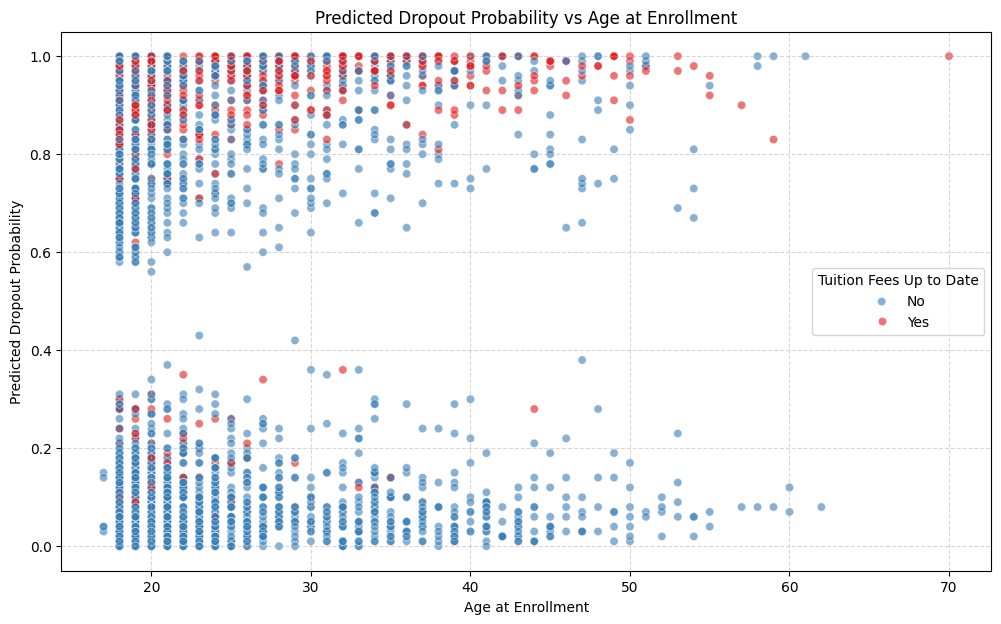

Average probability (Tuition NOT up to date): 83.59%
Average probability (Tuition UP TO DATE): 25.31%
Average reduction in dropout probability: 58.28%


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier

y = (df['Target'] == 'Dropout').astype(int)

X = df.select_dtypes(include=[np.number])

for col in ['Target_numeric', 'Target_Score', 'is_dropout']:
    if col in X.columns:
        X = X.drop(columns=[col])

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

df['dropout_prob'] = model.predict_proba(X)[:, 1]

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df,
    x='Age at enrollment',
    y='dropout_prob',
    hue='Tuition fees up to date',
    alpha=0.6,
    palette='Set1'
)
plt.title('Predicted Dropout Probability vs Age at Enrollment')
plt.xlabel('Age at Enrollment')
plt.ylabel('Predicted Dropout Probability')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Tuition Fees Up to Date', labels=['No', 'Yes'])
plt.show()

avg_no = df[df['Tuition fees up to date'] == 0]['dropout_prob'].mean()
avg_yes = df[df['Tuition fees up to date'] == 1]['dropout_prob'].mean()

print(f"Average probability (Tuition NOT up to date): {avg_no:.2%}")
print(f"Average probability (Tuition UP TO DATE): {avg_yes:.2%}")
print(f"Average reduction in dropout probability: {(avg_no - avg_yes):.2%}")

Average Reduction in Dropout Probability: 61.65%

Ages with the highest reduction in dropout probability:
Age at enrollment
57    0.99000
53    0.79800
49    0.74500
41    0.73963
55    0.67000
Name: reduction, dtype: float64


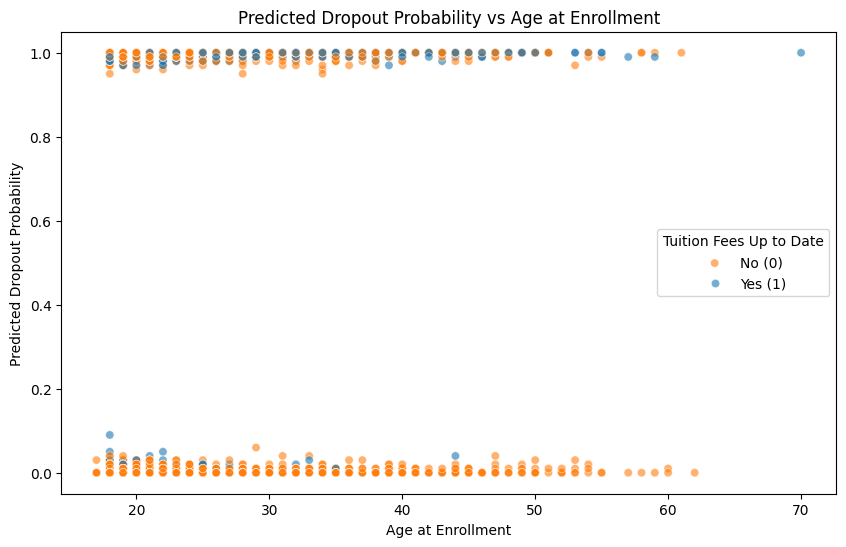

In [ ]:
df['is_dropout'] = (df['Target'] == 'Dropout').astype(int)
X = df.drop(columns=['Target', 'is_dropout'])

X = X.select_dtypes(include=[np.number])

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, df['is_dropout'])

df['dropout_prob'] = model.predict_proba(X)[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age at enrollment', y='dropout_prob',
                hue='Tuition fees up to date', alpha=0.6)
plt.title('Predicted Dropout Probability vs Age at Enrollment')
plt.xlabel('Age at Enrollment')
plt.ylabel('Predicted Dropout Probability')
plt.legend(title='Tuition Fees Up to Date', labels=['No (0)', 'Yes (1)'])
plt.savefig('dropout_analysis.png')

age_stats = df.groupby(['Age at enrollment', 'Tuition fees up to date'])['dropout_prob'].mean().unstack()
age_stats['reduction'] = age_stats[0] - age_stats[1]

avg_no = df[df['Tuition fees up to date'] == 0]['dropout_prob'].mean()
avg_yes = df[df['Tuition fees up to date'] == 1]['dropout_prob'].mean()

print(f"Average Reduction in Dropout Probability: {(avg_no - avg_yes):.2%}")
print("\nAges with the highest reduction in dropout probability:")
print(age_stats['reduction'].sort_values(ascending=False).head(5))

Model Accuracy: 1.0000
Confusion Matrix:
[[3003    0]
 [   0 1421]]


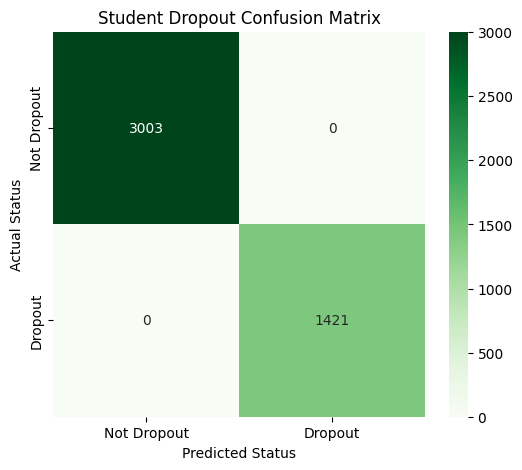

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

y = (df['Target'] == 'Dropout').astype(int)

X = df.select_dtypes(include=[np.number])

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

y_pred = model.predict(X)

accuracy = accuracy_score(y, y_pred)
conf_matrix = confusion_matrix(y, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Dropout', 'Dropout'],
            yticklabels=['Not Dropout', 'Dropout'])
plt.title('Student Dropout Confusion Matrix')
plt.ylabel('Actual Status')
plt.xlabel('Predicted Status')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


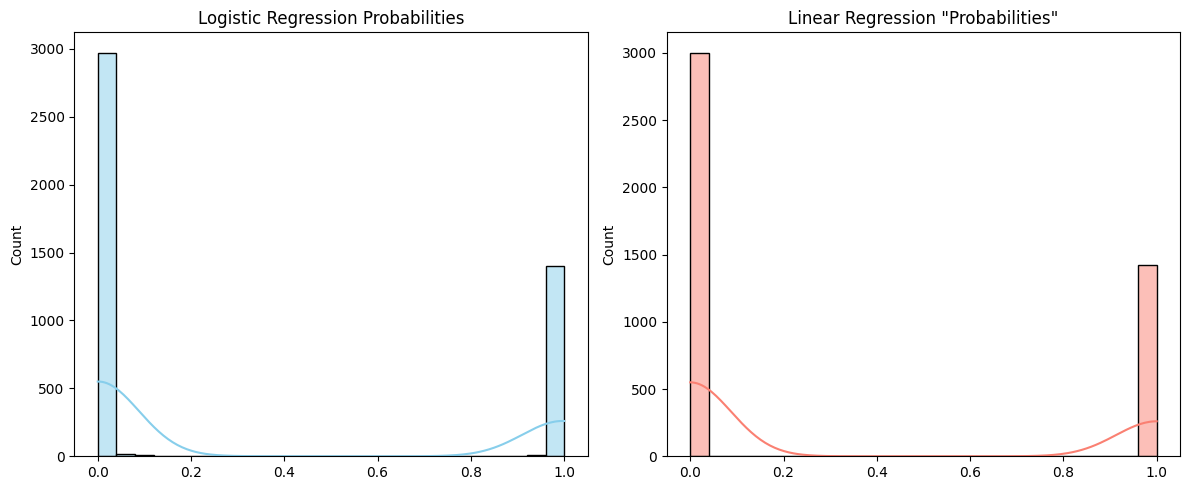

Logistic Accuracy: 100.00%
Linear Accuracy: 100.00%


In [ ]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error

y = (df['Target'] == 'Dropout').astype(int)
X = df.select_dtypes(include=[np.number])

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X, y)
log_probs = log_reg.predict_proba(X)[:, 1]

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_probs = lin_reg.predict(X)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(log_probs, bins=25, color='skyblue', kde=True)
plt.title('Logistic Regression Probabilities')

plt.subplot(1, 2, 2)
sns.histplot(lin_probs, bins=25, color='salmon', kde=True)
plt.title('Linear Regression "Probabilities"')

plt.tight_layout()
plt.show()

log_acc = accuracy_score(y, log_reg.predict(X))
lin_acc = accuracy_score(y, (lin_probs >= 0.5).astype(int))

print(f"Logistic Accuracy: {log_acc:.2%}")
print(f"Linear Accuracy: {lin_acc:.2%}")

The students that are most at risk are the ones that have compounding risk factors. Such as those who are behind on tuition, failed all credits in their first semester, and are over the age of 30 put all together into one student. Also, students with no early progress or students who are debtors, but do not have a scholarship. The biggest issue seems to be tuition so an intervention that could be made is to find financial aid for students that are behind even if its in the form of a small micro scholarship with a contingency that the student gets above a certian gpa.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 70.46%
Classes Predicted: ['Dropout' 'Graduate']


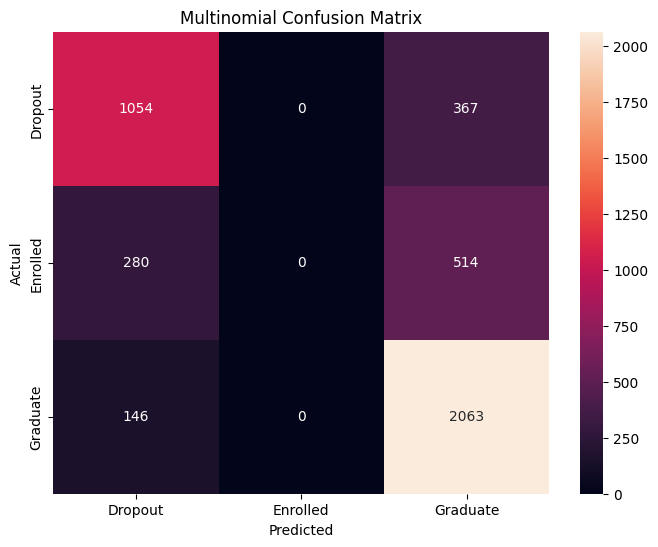

Highest probability assigned to Dropout: 96.02%
Highest probability assigned to Enrolled: 32.78%
Highest probability assigned to Graduate: 99.97%


In [ ]:
from sklearn.linear_model import LogisticRegression

df = pd.read_csv('data.csv', sep=';')

X = df[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']]
y = df['Target']

model = LogisticRegression(multi_class='multinomial', max_iter=1000)
model.fit(X, y)

y_pred = model.predict(X)
y_probs = model.predict_proba(X)

cm = confusion_matrix(y, y_pred, labels=model.classes_)
print(f"Accuracy: {accuracy_score(y, y_pred):.2%}")
print("Classes Predicted:", np.unique(y_pred))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Multinomial Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

max_probs = y_probs.max(axis=0)
for cls, prob in zip(model.classes_, max_probs):
    print(f"Highest probability assigned to {cls}: {prob:.2%}")

In [ ]:
X = df[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']]
y = df['Target']

model = LogisticRegression(multi_class='multinomial', max_iter=1000)
model.fit(X, y)

y_pred = model.predict(X)
print("Hard Classification (Classes Predicted):", np.unique(y_pred))

cm = confusion_matrix(y, y_pred, labels=model.classes_)
print("Confusion Matrix:\n", cm)
print(f"Accuracy: {accuracy_score(y, y_pred):.4f}")

y_probs = model.predict_proba(X)
enrolled_idx = list(model.classes_).index('Enrolled')
max_enrolled_prob = np.max(y_probs[:, enrolled_idx])

print(f"Highest probability assigned to 'Enrolled' for any student: {max_enrolled_prob:.2%}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Hard Classification (Classes Predicted): ['Dropout' 'Graduate']
Confusion Matrix:
 [[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]
Accuracy: 0.7046
Highest probability assigned to 'Enrolled' for any student: 32.78%


The model had an overall accuracy of 70.46% and was fairly successful for both the dropout and graduate categories, but the enrolled was where the model struggled the most. The hard classification does not predict every class, but the predicted probabilites mathematically did.

3.

In [1]:
import pandas as pd

df = pd.read_csv('cirrhosis.csv')

columns_to_keep = ['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']
df_filtered = df[columns_to_keep]

print("Missing values before handling:")
print(df_filtered.isnull().sum())

#Drug is missing 106 values (likely non-randomized patients not in the trial).
#Stage is missing 6 values.
#Dropped the rows with missing values
df_clean = df_filtered.dropna()

print("\nMissing values after handling:")
print(df_clean.isnull().sum())
print(f"\nFinal dataset shape: {df_clean.shape}")

Missing values before handling:
Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64

Missing values after handling:
Bilirubin    0
Edema        0
Drug         0
Stage        0
Status       0
dtype: int64

Final dataset shape: (312, 5)


In [2]:
import statsmodels.formula.api as smf

df_clean['Alive'] = df_clean['Status'].apply(lambda x: 1 if x in ['C', 'CL'] else 0)

formula = 'Alive ~ Bilirubin + C(Drug, Treatment("Placebo")) + C(Edema, Treatment("N"))'
model = smf.logit(formula, data=df_clean).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.530596
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Alive   No. Observations:                  312
Model:                          Logit   Df Residuals:                      307
Method:                           MLE   Df Model:                            4
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.2119
Time:                        16:37:18   Log-Likelihood:                -165.55
converged:                       True   LL-Null:                       -210.06
Covariance Type:            nonrobust   LLR p-value:                 2.117e-18
                                                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------
Intercept                       

/tmp/ipykernel_6432/2802437225.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Alive'] = df_clean['Status'].apply(lambda x: 1 if x in ['C', 'CL'] else 0)


No, the drug does not improve survival-ability since the treatment drug does not have a statistically significant effect on survival compared to the placebo.
Higher Bilrubin predicts a lower survival rate.
Mild edema shows a slight trend towards lower survival while serious edema shows a drastically much lower surival that is also statistically significant.

Optimization terminated successfully.
         Current function value: 0.530596
         Iterations 7
On average, the drug changes survival probability by: -0.0451 (-4.51%)


/tmp/ipykernel_6432/2600809633.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Predicted_Survival_Prob'] = model.predict(df_clean)


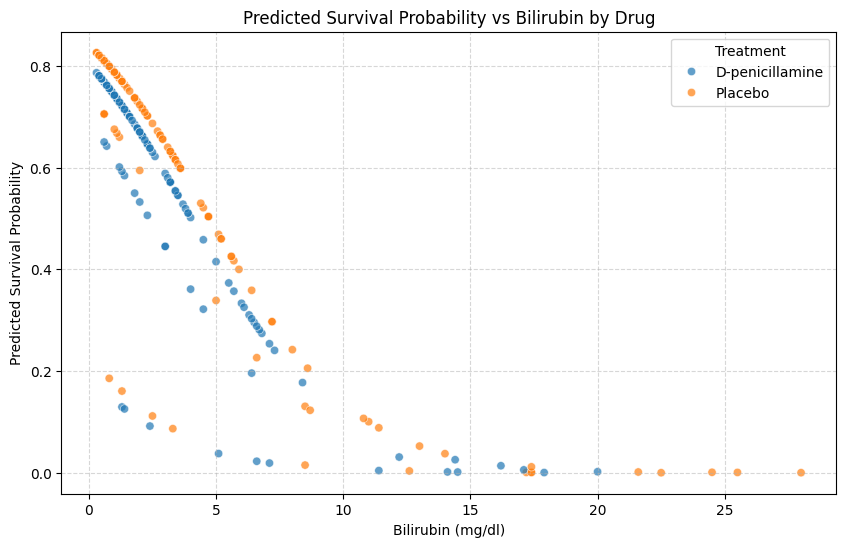

In [3]:
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

formula = 'Alive ~ Bilirubin + C(Drug, Treatment("Placebo")) + C(Edema, Treatment("N"))'
model = smf.logit(formula, data=df_clean).fit()

df_clean['Predicted_Survival_Prob'] = model.predict(df_clean)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean,
    x='Bilirubin',
    y='Predicted_Survival_Prob',
    hue='Drug',
    alpha=0.7
)
plt.title('Predicted Survival Probability vs Bilirubin by Drug')
plt.xlabel('Bilirubin (mg/dl)')
plt.ylabel('Predicted Survival Probability')
plt.legend(title='Treatment')
plt.grid(True, linestyle='--', alpha=0.5)

df_placebo = df_clean.copy()
df_placebo['Drug'] = 'Placebo'

df_drug = df_clean.copy()
df_drug['Drug'] = 'D-penicillamine'

prob_placebo = model.predict(df_placebo)
prob_drug = model.predict(df_drug)

mean_diff = (prob_drug - prob_placebo).mean()

print(f"On average, the drug changes survival probability by: {mean_diff:.4f} ({mean_diff * 100:.2f}%)")

No values of Bilirubin seem to increase patient survial rate.

In [4]:
from sklearn.metrics import confusion_matrix, accuracy_score

columns_to_keep = ['Bilirubin', 'Edema', 'Drug', 'Status']
df_clean = df[columns_to_keep].dropna().copy()

df_clean['Alive'] = df_clean['Status'].apply(lambda x: 1 if x in ['C', 'CL'] else 0)

formula = 'Alive ~ Bilirubin + C(Drug, Treatment("Placebo")) + C(Edema, Treatment("N"))'
model = smf.logit(formula, data=df_clean).fit(disp=0)

probabilities = model.predict(df_clean)

predictions = (probabilities >= 0.5).astype(int)

cm = confusion_matrix(df_clean['Alive'], predictions)
accuracy = accuracy_score(df_clean['Alive'], predictions)

print("Confusion Matrix:")
print(cm)
print(f"Accuracy: {accuracy:.4f}")

Confusion Matrix:
[[ 57  68]
 [ 14 173]]
Accuracy: 0.7372


Logistic Regression Accuracy: 0.7372
Linear Model (OLS) Accuracy:  0.7212

Impossible OLS Predictions (p < 0 or p > 1): 15
OLS Probability Range:   -0.4417 to 0.7739
Logit Probability Range: 0.0001 to 0.8258


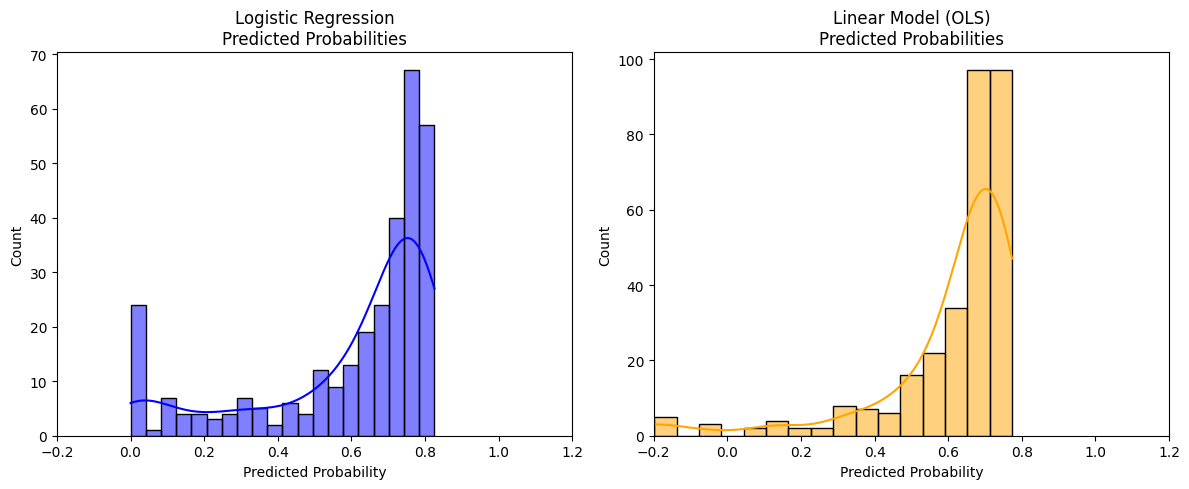

In [5]:
from sklearn.metrics import accuracy_score

formula = 'Alive ~ Bilirubin + C(Drug, Treatment("Placebo")) + C(Edema, Treatment("N"))'

model_logit = smf.logit(formula, data=df_clean).fit(disp=0)
prob_logit = model_logit.predict(df_clean)
pred_logit = (prob_logit >= 0.5).astype(int)
acc_logit = accuracy_score(df_clean['Alive'], pred_logit)

model_ols = smf.ols(formula, data=df_clean).fit()
prob_ols = model_ols.predict(df_clean)
pred_ols = (prob_ols >= 0.5).astype(int)
acc_ols = accuracy_score(df_clean['Alive'], pred_ols)

print(f"Logistic Regression Accuracy: {acc_logit:.4f}")
print(f"Linear Model (OLS) Accuracy:  {acc_ols:.4f}")

out_of_bounds = ((prob_ols < 0) | (prob_ols > 1)).sum()
print(f"\nImpossible OLS Predictions (p < 0 or p > 1): {out_of_bounds}")
print(f"OLS Probability Range:   {prob_ols.min():.4f} to {prob_ols.max():.4f}")
print(f"Logit Probability Range: {prob_logit.min():.4f} to {prob_logit.max():.4f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(prob_logit, bins=20, kde=True, color='blue')
plt.title('Logistic Regression\nPredicted Probabilities')
plt.xlabel('Predicted Probability')
plt.xlim(-0.2, 1.2)
plt.subplot(1, 2, 2)
sns.histplot(prob_ols, bins=20, kde=True, color='orange')
plt.title('Linear Model (OLS)\nPredicted Probabilities')
plt.xlabel('Predicted Probability')
plt.xlim(-0.2, 1.2)

plt.tight_layout()

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

columns_to_keep = ['Bilirubin', 'Edema', 'Stage']

df_clean = df[columns_to_keep].dropna().copy()

X = pd.get_dummies(df_clean[['Bilirubin', 'Edema']], drop_first=True)
y = df_clean['Stage']

model = LogisticRegression(multi_class='multinomial', max_iter=1000)
model.fit(X, y)

predictions = model.predict(X)

labels = sorted(y.unique())
cm = confusion_matrix(y, predictions, labels=labels)
accuracy = accuracy_score(y, predictions)

print("Classes (Stages):", labels)
print("Confusion Matrix:\n", cm)
print(f"Accuracy: {accuracy:.4f}")

Classes (Stages): [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
Confusion Matrix:
 [[  0   0  20   1]
 [  0   0  82  10]
 [  0   0 130  25]
 [  0   0  93  51]]
Accuracy: 0.4393


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


The model did not perform will with an overall accuracy of 43.93%.

In [8]:
import numpy as np
from sklearn.linear_model import LogisticRegression

columns_to_keep = ['Bilirubin', 'Edema', 'Stage']
df_clean = df[columns_to_keep].dropna().copy()

X = pd.get_dummies(df_clean[['Bilirubin', 'Edema']], drop_first=True)
y = df_clean['Stage']

model = LogisticRegression(multi_class='multinomial', max_iter=1000)
model.fit(X, y)

hard_predictions = model.predict(X)
unique_hard_preds = np.unique(hard_predictions)
print(f"Classes predicted by hard classification: {unique_hard_preds}")

probabilities = model.predict_proba(X)

prob_mins = probabilities.min(axis=0)
prob_maxs = probabilities.max(axis=0)

print("\nProbability ranges assigned across all patients:")
classes = sorted(y.unique())
for i, stage in enumerate(classes):
    print(f"Stage {int(stage)}: Min Prob = {prob_mins[i]:.4f}, Max Prob = {prob_maxs[i]:.4f}")

Classes predicted by hard classification: [3. 4.]

Probability ranges assigned across all patients:
Stage 1: Min Prob = 0.0000, Max Prob = 0.0861
Stage 2: Min Prob = 0.0295, Max Prob = 0.2573
Stage 3: Min Prob = 0.0989, Max Prob = 0.4041
Stage 4: Min Prob = 0.2642, Max Prob = 0.8716


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


No, the hard classification only predicts stages 3 and 4, not 1 and 2. The predicted probabilites do predict every class when we use .predict_proba and it outputs an array with the 4 probabilites.